In [1]:
# Cell 1: imports and display options

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)


In [2]:
import os
os.chdir('/Users/zolf/Desktop/T1')

In [3]:
# Cell 2: load raw dataset (change filename if needed)

df = pd.read_csv("DatabasePietro.xlsx - genotipi28nov.csv", decimal=",")  # <--  real filename here

print("Shape:", df.shape)
df.head()


Shape: (165, 44)


,ID,MAOAuVNTR,Eta,QI,adhd,farmaco,cse,emotional,neglect,physical,AD,RBB,AB,TOTINT,TOTEXT,APQ_POS,APQ_NEG,APSD_CU,APSD_IMP,APSD_NARCI,Sintomi_DOP,ER_paura,ER_tristezza,ER_rabbia,ER_felicità,ER_disgusto,FC_E_AN,FC_E_HA,FC_E_SA,FC_E_FE,FC_E_DI,FFD_E_AN,FFD_E_HA,FFD_E_SA,FFD_E_FE,FFD_E_DI,FD_E_AN,FD_E_HA,FD_E_SA,FD_E_FE,FD_E_DI,APSD_CU1,AQ_Predatoria1,ICU_Total1
0,1,"4,0",7,122,1,2,3,1,1,1,55,63,65,57,64,48,13,4,4,4,7,0,3,3,4,4,"27,27","19,82","15,82","27,74","22,60","216,85","229,38","262,78","243,70","308,48","31,31","23,27","19,98","29,42","27,68",6.0,1.0,22
1,2,"4,0",9,90,1,1,2,2,1,1,73,63,70,68,68,52,20,1,6,4,5,3,5,3,4,0,"52,90","52,15","73,61","75,76","58,88","127,23","215,43","221,03","160,28","168,73","54,45","50,27","76,11","73,37","61,44",3.0,0.0,14
2,3,"3,0",10,97,1,1,2,1,1,1,70,71,81,72,75,56,20,4,7,5,4,2,1,2,4,4,"34,40","17,11","44,34","44,71","29,29","190,65","188,25","195,35","165,10","189,10","35,74","15,79","43,01","40,00","26,80",8.0,2.0,12
3,4,"4,0",7,111,2,2,4,1,1,1,57,53,64,50,61,52,14,4,5,3,6,4,2,4,3,0,"51,83","46,88","55,83","42,92","44,06","152,20","154,30","156,35","133,38","235,65","51,62","43,47","50,55","47,68","44,38",3.0,0.0,12
4,5,"3,0",9,100,1,1,3,1,1,1,82,64,70,75,70,52,11,4,5,2,5,4,3,3,4,3,"45,20","16,67","44,83","19,52","19,29","161,03","68,85","164,93","80,20","94,05","46,86","15,98","45,78","17,79","19,04",5.0,1.0,45


In [7]:
# Cell 3: clean column names 

# strip leading/trailing spaces and remove internal spaces
df.columns = df.columns.str.strip().str.replace(r"\s+", "", regex=True)

print("Column names after cleaning:")
print(df.columns.tolist())


Column names after cleaning:
['ID', 'MAOAuVNTR', 'Eta', 'QI', 'adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical', 'AD', 'RBB', 'AB', 'TOTINT', 'TOTEXT', 'APQ_POS', 'APQ_NEG', 'APSD_CU', 'APSD_IMP', 'APSD_NARCI', 'Sintomi_DOP', 'ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto', 'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI', 'APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']


In [9]:
# Cell 4: replace weird placeholders with NaN

placeholders = ['#NULL!', 'NULL', 'NaN', 'NA', 'n/a', 'N/A', ' ', '']
df = df.replace(placeholders, np.nan)

print("Done replacing placeholders. Any NaNs now:", df.isna().sum().sum())


Done replacing placeholders. Any NaNs now: 922


In [11]:
# Cell 5: fix numeric-like columns (commas, percents)

for col in df.columns:
    s = df[col].astype(str)

    # If there are % values → remove % and convert comma to dot
    if s.str.contains('%').any():
        s = s.str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')
    
    # Else, if there are commas but no % → treat as decimal comma
    elif s.str.contains(',').any():
        s = s.str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')

    # Otherwise, try numeric conversion but don't force
    else:
        try:
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except Exception:
            pass

print("Dtypes after numeric cleaning:")
print(df.dtypes)


Dtypes after numeric cleaning:
ID                  int64
MAOAuVNTR         float64
Eta               float64
QI                float64
adhd              float64
farmaco           float64
cse               float64
emotional         float64
neglect           float64
physical          float64
AD                  int64
RBB                 int64
AB                  int64
TOTINT              int64
TOTEXT              int64
APQ_POS           float64
APQ_NEG           float64
APSD_CU             int64
APSD_IMP            int64
APSD_NARCI          int64
Sintomi_DOP       float64
ER_paura          float64
ER_tristezza      float64
ER_rabbia         float64
ER_felicità       float64
ER_disgusto       float64
FC_E_AN           float64
FC_E_HA           float64
FC_E_SA           float64
FC_E_FE           float64
FC_E_DI           float64
FFD_E_AN          float64
FFD_E_HA          float64
FFD_E_SA          float64
FFD_E_FE          float64
FFD_E_DI          float64
FD_E_AN           float64
FD_E_HA

In [13]:
# Cell 6: define column groups

# main continuous targets
target_cont = ['APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']

# gene variant (categorical)
gene_vars = ['MAOAuVNTR']

# categorical clinical-like variables
class_vars = ['adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical']

# eye-tracking metrics
eye_tracking_vars = [
    'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI',
    'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI',
    'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI'
]

# emotion recognition variables
er_cols = ['ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto']

# other numeric-like vars you mentioned
other_numeric = ['Eta', 'QI', 'APQ_POS', 'APQ_NEG', 'Sintomi_DOP']

print("Targets:", target_cont)
print("Eye-tracking vars:", eye_tracking_vars)


Targets: ['APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']
Eye-tracking vars: ['FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI']


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [17]:
# Cell 7: ensure numeric where expected

numeric_like = target_cont + eye_tracking_vars + er_cols + other_numeric

for col in numeric_like:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric-like columns converted. Sample dtypes:")
print(df[numeric_like].dtypes.dropna())


Numeric-like columns converted. Sample dtypes:
APSD_CU1          float64
AQ_Predatoria1    float64
ICU_Total1        float64
FC_E_AN           float64
FC_E_HA           float64
FC_E_SA           float64
FC_E_FE           float64
FC_E_DI           float64
FFD_E_AN          float64
FFD_E_HA          float64
FFD_E_SA          float64
FFD_E_FE          float64
FFD_E_DI          float64
FD_E_AN           float64
FD_E_HA           float64
FD_E_SA           float64
FD_E_FE           float64
FD_E_DI           float64
ER_paura          float64
ER_tristezza      float64
ER_rabbia         float64
ER_felicità       float64
ER_disgusto       float64
Eta               float64
QI                float64
APQ_POS           float64
APQ_NEG           float64
Sintomi_DOP       float64
dtype: object


In [19]:
# Cell 8: handle missing values

# numeric columns
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical / object columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after filling:", df.isna().sum().sum())


Total missing values after filling: 0


In [21]:
# Cell 9: create binary targets from continuous targets

for col in target_cont:
    if col in df.columns:
        median_val = df[col].median()
        df[col + '_binary'] = (df[col] > median_val).astype(int)
        print(f"{col}: median = {median_val:.3f}")

print("\nBinary target columns created:")
print([c for c in df.columns if c.endswith('_binary')])


APSD_CU1: median = 4.000
AQ_Predatoria1: median = 1.000
ICU_Total1: median = 16.000

Binary target columns created:
['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary']


In [67]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Your data
data = {
    'Target': ['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary'],
    'Majority': [103, 125, 108],
    'Minority': [62, 40, 57]
}

# Create DataFrame
df_counts = pd.DataFrame(data)

# Calculate metrics
df_counts['Total'] = df_counts['Majority'] + df_counts['Minority']
df_counts['Ratio (maj/min)'] = df_counts['Majority'] / df_counts['Minority']
df_counts['Minority %'] = (df_counts['Minority'] / df_counts['Total']) * 100

# Assign severity based on ratio
def assign_severity(ratio, minority_pct):
    if ratio >= 3 or minority_pct < 20:
        return 'High'
    elif ratio >= 1.5 or minority_pct < 40:
        return 'Moderate'
    else:
        return 'Normal'

# Custom severity for your specific case
def custom_severity(target, ratio):
    if target == 'AQ_Predatoria1_binary':
        return 'Moderate to High'
    else:
        return 'Moderate'

df_counts['Severity'] = df_counts.apply(
    lambda x: custom_severity(x['Target'], x['Ratio (maj/min)']), axis=1
)

# Format the percentage column
df_counts['Minority %'] = df_counts['Minority %'].apply(lambda x: f"{x:.1f}%")
df_counts['Ratio (maj/min)'] = df_counts['Ratio (maj/min)'].apply(lambda x: f"{x:.3f}")

# Select columns for final table
final_table = df_counts[['Target', 'Ratio (maj/min)', 'Minority %', 'Severity']]

In [69]:
print("=== Class Imbalance Summary Table ===\n")
print(final_table.to_string(index=False))

=== Class Imbalance Summary Table ===

               Target Ratio (maj/min) Minority %         Severity
      APSD_CU1_binary           1.661      37.6%         Moderate
AQ_Predatoria1_binary           3.125      24.2% Moderate to High
    ICU_Total1_binary           1.895      34.5%         Moderate


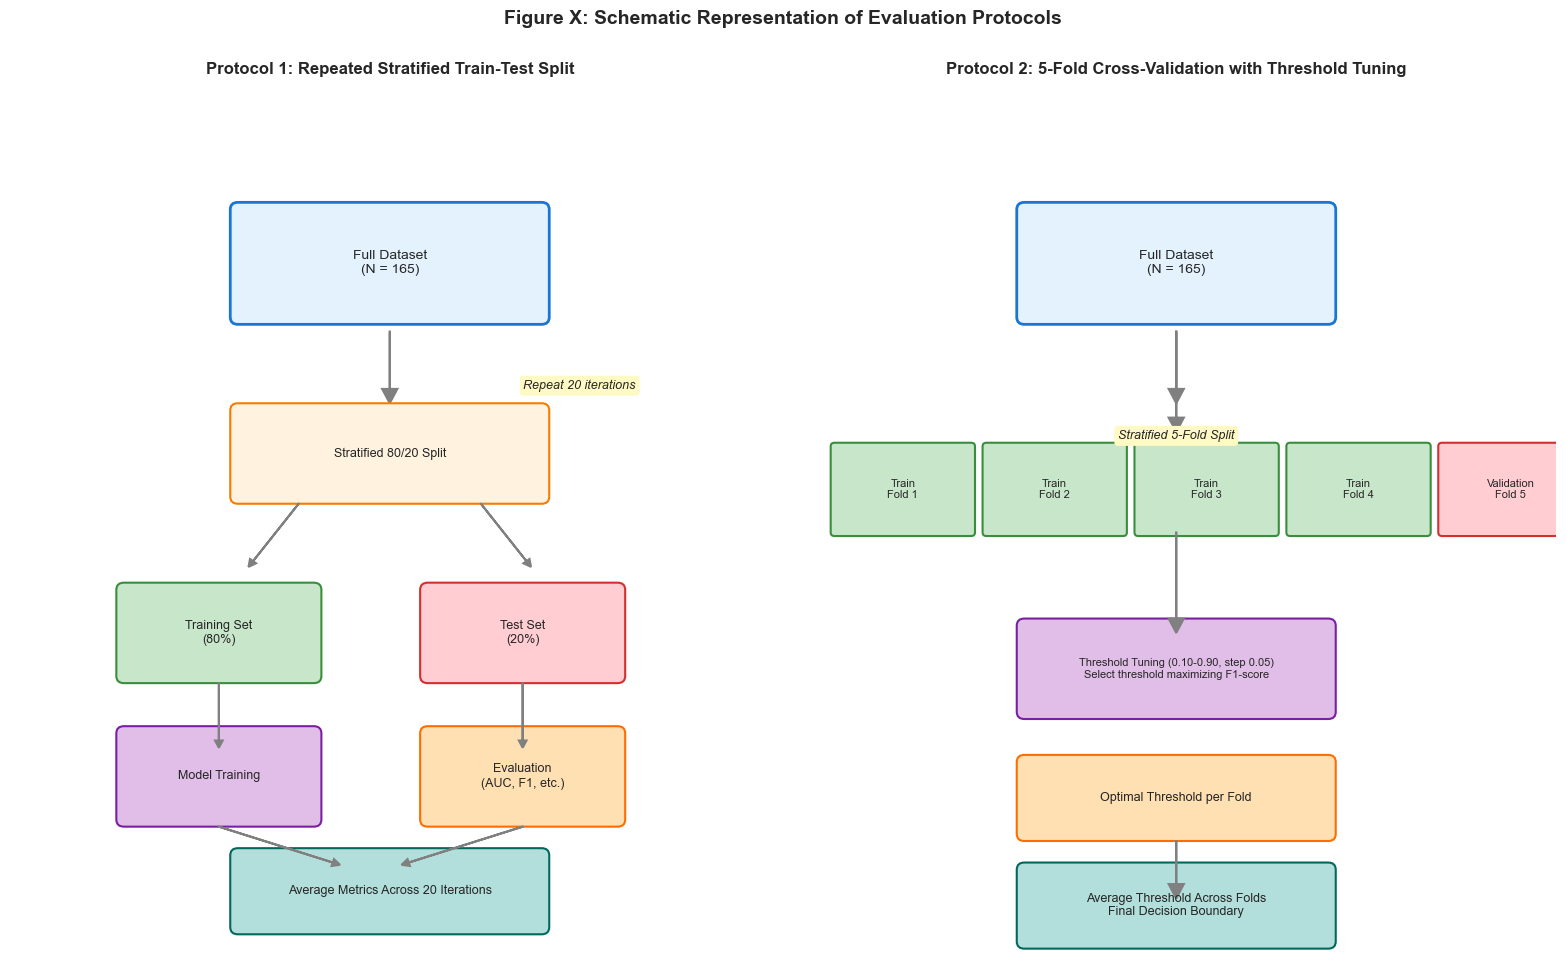

In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.lines as mlines

fig, ax = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle('Figure X: Schematic Representation of Evaluation Protocols', 
             fontsize=14, fontweight='bold', y=0.98)

# ============================================
# PROTOCOL 1: Repeated Train-Test Split
# ============================================
ax[0].set_xlim(0, 10)
ax[0].set_ylim(0, 12)
ax[0].axis('off')
ax[0].set_title('Protocol 1: Repeated Stratified Train-Test Split', 
                fontsize=12, fontweight='bold', pad=20)

# Dataset box
dataset1 = FancyBboxPatch((3, 9), 4, 1.5, boxstyle="round,pad=0.1",
                          facecolor='#e3f2fd', edgecolor='#1976d2', linewidth=2)
ax[0].add_patch(dataset1)
ax[0].text(5, 9.75, 'Full Dataset\n(N = 165)', ha='center', va='center', fontsize=10)

# Arrow down
ax[0].arrow(5, 8.8, 0, -0.8, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

# Loop text
ax[0].text(7.5, 8, 'Repeat 20 iterations', ha='center', fontsize=9, style='italic',
           bbox=dict(boxstyle="round,pad=0.3", facecolor='#fff9c4', edgecolor='none'))

# Split box
split = FancyBboxPatch((3, 6.5), 4, 1.2, boxstyle="round,pad=0.1",
                       facecolor='#fff3e0', edgecolor='#f57c00', linewidth=1.5)
ax[0].add_patch(split)
ax[0].text(5, 7.1, 'Stratified 80/20 Split', ha='center', va='center', fontsize=9)

# Train and Test boxes
train = FancyBboxPatch((1.5, 4), 2.5, 1.2, boxstyle="round,pad=0.1",
                       facecolor='#c8e6c9', edgecolor='#388e3c', linewidth=1.5)
ax[0].add_patch(train)
ax[0].text(2.75, 4.6, 'Training Set\n(80%)', ha='center', va='center', fontsize=9)

test = FancyBboxPatch((5.5, 4), 2.5, 1.2, boxstyle="round,pad=0.1",
                      facecolor='#ffcdd2', edgecolor='#d32f2f', linewidth=1.5)
ax[0].add_patch(test)
ax[0].text(6.75, 4.6, 'Test Set\n(20%)', ha='center', va='center', fontsize=9)

# Arrows from split to train/test
ax[0].arrow(3.8, 6.4, -0.6, -0.8, head_width=0.1, head_length=0.1, fc='gray', ec='gray')
ax[0].arrow(6.2, 6.4, 0.6, -0.8, head_width=0.1, head_length=0.1, fc='gray', ec='gray')

# Model training
model = FancyBboxPatch((1.5, 2), 2.5, 1.2, boxstyle="round,pad=0.1",
                       facecolor='#e1bee7', edgecolor='#7b1fa2', linewidth=1.5)
ax[0].add_patch(model)
ax[0].text(2.75, 2.6, 'Model Training', ha='center', va='center', fontsize=9)

# Evaluation
eval_box = FancyBboxPatch((5.5, 2), 2.5, 1.2, boxstyle="round,pad=0.1",
                          facecolor='#ffe0b2', edgecolor='#ff6d00', linewidth=1.5)
ax[0].add_patch(eval_box)
ax[0].text(6.75, 2.6, 'Evaluation\n(AUC, F1, etc.)', ha='center', va='center', fontsize=9)

# Arrows to evaluation
ax[0].arrow(2.75, 3.9, 0, -0.8, head_width=0.1, head_length=0.1, fc='gray', ec='gray')
ax[0].arrow(6.75, 3.9, 0, -0.8, head_width=0.1, head_length=0.1, fc='gray', ec='gray')

# Metrics averaging
avg = FancyBboxPatch((3, 0.5), 4, 1, boxstyle="round,pad=0.1",
                     facecolor='#b2dfdb', edgecolor='#00695c', linewidth=1.5)
ax[0].add_patch(avg)
ax[0].text(5, 1, 'Average Metrics Across 20 Iterations', ha='center', va='center', fontsize=9)

# Arrows from train/test to averaging
ax[0].arrow(2.75, 1.9, 1.5, -0.5, head_width=0.1, head_length=0.1, fc='gray', ec='gray')
ax[0].arrow(6.75, 1.9, -1.5, -0.5, head_width=0.1, head_length=0.1, fc='gray', ec='gray')

# ============================================
# PROTOCOL 2: 5-Fold CV with Threshold Tuning
# ============================================
ax[1].set_xlim(0, 10)
ax[1].set_ylim(0, 12)
ax[1].axis('off')
ax[1].set_title('Protocol 2: 5-Fold Cross-Validation with Threshold Tuning', 
                fontsize=12, fontweight='bold', pad=20)

# Dataset box
dataset2 = FancyBboxPatch((3, 9), 4, 1.5, boxstyle="round,pad=0.1",
                          facecolor='#e3f2fd', edgecolor='#1976d2', linewidth=2)
ax[1].add_patch(dataset2)
ax[1].text(5, 9.75, 'Full Dataset\n(N = 165)', ha='center', va='center', fontsize=10)

# Arrow down
ax[1].arrow(5, 8.8, 0, -0.8, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

# 5-Fold representation
fold_positions = [(0.5, 6), (2.5, 6), (4.5, 6), (6.5, 6), (8.5, 6)]
fold_colors = ['#c8e6c9', '#c8e6c9', '#c8e6c9', '#c8e6c9', '#ffcdd2']

for i, (x, y) in enumerate(fold_positions):
    fold = FancyBboxPatch((x, y), 1.8, 1.2, boxstyle="round,pad=0.05",
                          facecolor=fold_colors[i], edgecolor='#388e3c' if i < 4 else '#d32f2f', 
                          linewidth=1.5)
    ax[1].add_patch(fold)
    
    if i < 4:
        ax[1].text(x+0.9, y+0.6, f'Train\nFold {i+1}', ha='center', va='center', fontsize=8)
    else:
        ax[1].text(x+0.9, y+0.6, f'Validation\nFold {i+1}', ha='center', va='center', fontsize=8)

# Arrow from dataset to folds
ax[1].arrow(5, 8.8, 0, -1.2, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

# Text for cross-validation process
ax[1].text(5, 7.3, 'Stratified 5-Fold Split', ha='center', fontsize=9, style='italic',
           bbox=dict(boxstyle="round,pad=0.3", facecolor='#fff9c4', edgecolor='none'))

# Threshold tuning box
tuning = FancyBboxPatch((3, 3.5), 4, 1.2, boxstyle="round,pad=0.1",
                        facecolor='#e1bee7', edgecolor='#7b1fa2', linewidth=1.5)
ax[1].add_patch(tuning)
ax[1].text(5, 4.1, 'Threshold Tuning (0.10-0.90, step 0.05)\nSelect threshold maximizing F1-score', 
           ha='center', va='center', fontsize=8)

# Arrow from folds to tuning
ax[1].arrow(5, 6, 0, -1.2, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

# Optimal threshold per fold
thresholds = FancyBboxPatch((3, 1.8), 4, 1, boxstyle="round,pad=0.1",
                            facecolor='#ffe0b2', edgecolor='#ff6d00', linewidth=1.5)
ax[1].add_patch(thresholds)
ax[1].text(5, 2.3, 'Optimal Threshold per Fold', ha='center', va='center', fontsize=9)

# Final average threshold
final = FancyBboxPatch((3, 0.3), 4, 1, boxstyle="round,pad=0.1",
                       facecolor='#b2dfdb', edgecolor='#00695c', linewidth=1.5)
ax[1].add_patch(final)
ax[1].text(5, 0.8, 'Average Threshold Across Folds\nFinal Decision Boundary', 
           ha='center', va='center', fontsize=9)

# Arrow from thresholds to final
ax[1].arrow(5, 1.7, 0, -0.6, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

plt.tight_layout()
plt.savefig('evaluation_protocols_schematic.png', dpi=300, bbox_inches='tight', 
            facecolor='white')
plt.show()

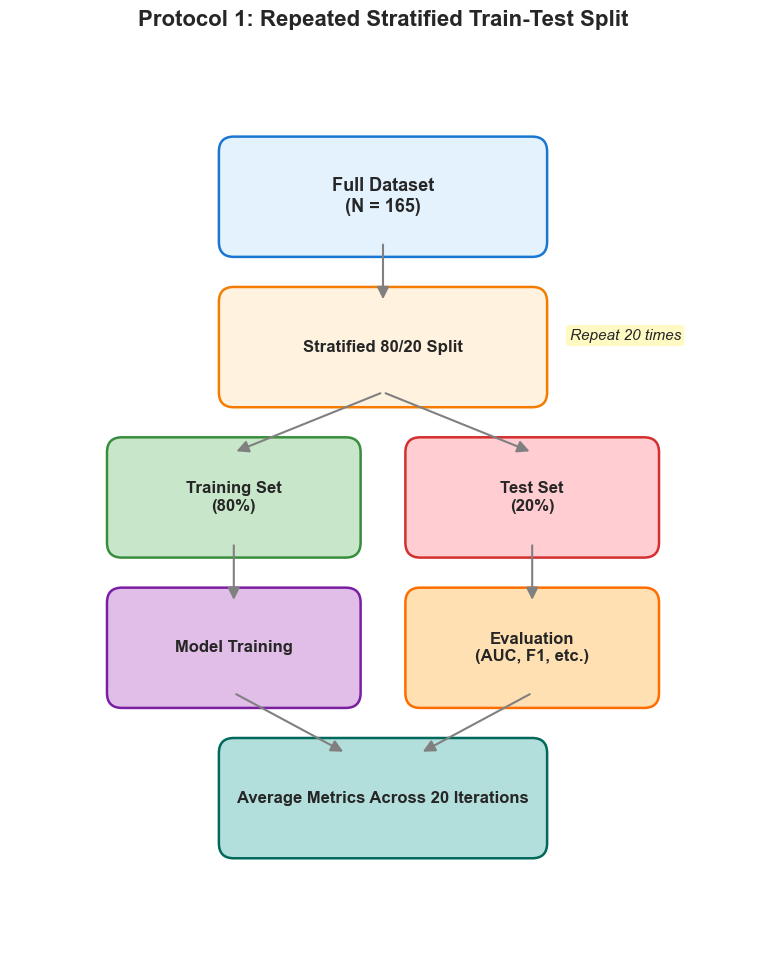

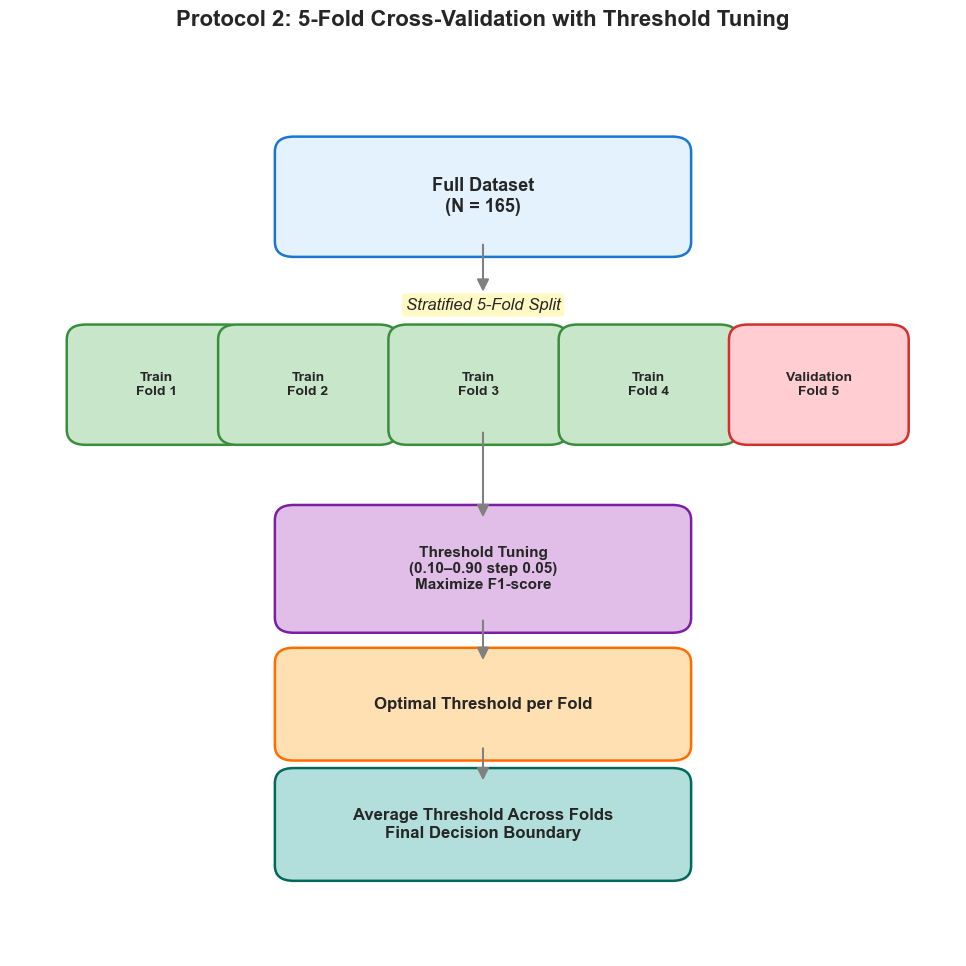

In [115]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ---------- Helper functions ----------
def add_box(ax, xy, width, height, text, fc, ec, fontsize=12):
    box = FancyBboxPatch(
        xy, width, height,
        boxstyle="round,pad=0.2",
        linewidth=1.8,
        facecolor=fc,
        edgecolor=ec
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width/2,
        xy[1] + height/2,
        text,
        ha='center',
        va='center',
        fontsize=fontsize,
        fontweight='bold'
    )
    return box


def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start, end,
        arrowstyle='-|>',
        mutation_scale=18,
        linewidth=1.5,
        color='gray'
    )
    ax.add_patch(arrow)


# ============================================
# PROTOCOL 1 (Separate Figure)
# ============================================
fig, ax = plt.subplots(figsize=(8, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

ax.set_title(
    'Protocol 1: Repeated Stratified Train-Test Split',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Boxes
add_box(ax, (3, 9.5), 4, 1.2, 'Full Dataset\n(N = 165)', '#e3f2fd', '#1976d2', 13)

add_box(ax, (3, 7.5), 4, 1.2, 'Stratified 80/20 Split', '#fff3e0', '#f57c00', 12)

add_box(ax, (1.5, 5.5), 3, 1.2, 'Training Set\n(80%)', '#c8e6c9', '#388e3c', 12)
add_box(ax, (5.5, 5.5), 3, 1.2, 'Test Set\n(20%)', '#ffcdd2', '#d32f2f', 12)

add_box(ax, (1.5, 3.5), 3, 1.2, 'Model Training', '#e1bee7', '#7b1fa2', 12)
add_box(ax, (5.5, 3.5), 3, 1.2, 'Evaluation\n(AUC, F1, etc.)', '#ffe0b2', '#ff6d00', 12)

add_box(ax, (3, 1.5), 4, 1.2,
        'Average Metrics Across 20 Iterations',
        '#b2dfdb', '#00695c', 12)

# Arrows
add_arrow(ax, (5, 9.5), (5, 8.7))
add_arrow(ax, (5, 7.5), (3, 6.7))
add_arrow(ax, (5, 7.5), (7, 6.7))

add_arrow(ax, (3, 5.5), (3, 4.7))
add_arrow(ax, (7, 5.5), (7, 4.7))

add_arrow(ax, (3, 3.5), (4.5, 2.7))
add_arrow(ax, (7, 3.5), (5.5, 2.7))

# Loop text
ax.text(7.5, 8.2, 'Repeat 20 times',
        fontsize=11, style='italic',
        bbox=dict(boxstyle="round", fc='#fff9c4'))

plt.tight_layout()
plt.savefig('protocol_1.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================
# PROTOCOL 2 (Separate Figure)
# ============================================
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

ax.set_title(
    'Protocol 2: 5-Fold Cross-Validation with Threshold Tuning',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Top box
add_box(ax, (3, 9.5), 4, 1.2, 'Full Dataset\n(N = 165)', '#e3f2fd', '#1976d2', 13)

# Folds (aligned better)
x_positions = [0.8, 2.4, 4.2, 6.0, 7.8]

for i, x in enumerate(x_positions):
    if i < 4:
        add_box(ax, (x, 7), 1.5, 1.2,
                f'Train\nFold {i+1}',
                '#c8e6c9', '#388e3c', 10)
    else:
        add_box(ax, (x, 7), 1.5, 1.2,
                f'Validation\nFold {i+1}',
                '#ffcdd2', '#d32f2f', 10)

# Text label
ax.text(5, 8.6, 'Stratified 5-Fold Split',
        ha='center',
        fontsize=12,
        style='italic',
        bbox=dict(boxstyle="round", fc='#fff9c4'))

# Tuning
add_box(ax, (3, 4.5), 4, 1.3,
        'Threshold Tuning\n(0.10–0.90 step 0.05)\nMaximize F1-score',
        '#e1bee7', '#7b1fa2', 11)

add_box(ax, (3, 2.8), 4, 1.1,
        'Optimal Threshold per Fold',
        '#ffe0b2', '#ff6d00', 12)

add_box(ax, (3, 1.2), 4, 1.1,
        'Average Threshold Across Folds\nFinal Decision Boundary',
        '#b2dfdb', '#00695c', 12)

# Arrows
add_arrow(ax, (5, 9.5), (5, 8.8))
add_arrow(ax, (5, 7), (5, 5.8))
add_arrow(ax, (5, 4.5), (5, 3.9))
add_arrow(ax, (5, 2.8), (5, 2.3))

plt.tight_layout()
plt.savefig('protocol_2.png', dpi=300, bbox_inches='tight')
plt.show()

In [87]:
import pandas as pd
from IPython.display import display, HTML

# Create the summary table with consistent column names
variables_data = [
    # ========== DEMOGRAPHIC & CLINICAL VARIABLES ==========
    ["QI", "Intelligence Quotient", "Wechsler Intelligence Scale for Children", "Cognitive"],
    ["Adhd", "ADHD Diagnosis", "Presence/absence of ADHD diagnosis (0=no, 1=yes)", "Clinical"],
    ["Cse", "Socioeconomic Status Index", "Composite measure of socioeconomic status", "Demographic"],
    ["Sintomi_DOP", "Oppositional Defiant Symptoms", "Severity of oppositional defiant symptoms", "Clinical"],
    
    # ========== MALTREATMENT INDEX ==========
    ["Maltreatment_Emotional", "Emotional Maltreatment", "Being ridiculed, intimidated, exposed to hostility or violence", "Maltreatment"],
    ["Maltreatment_Neglect", "Neglect", "Left without supervision, insufficient nutrition, left with dangerous individuals", "Maltreatment"],
    ["Maltreatment_Physical", "Physical Maltreatment", "Intentionally physically hurt, suffocated, burned", "Maltreatment"],
    
    # ========== CHILD BEHAVIOR CHECKLIST (CBCL) ==========
    ["AD", "Anxiety-Depression", "Symptoms of anxiety and depression", "Behavior"],
    ["RBB", "Rule Breaking Behavior", "Behaviors violating rules and norms", "Behavior"],
    ["AB", "Aggressive Behavior", "Physically and verbally aggressive behaviors", "Behavior"],
    ["DP", "Dysregulation Profile", "Sum of aggressive behavior, attention problems, and anxiety-depression scores", "Behavior"],
    ["TOTINT", "Total Internalizing Problems", "Global internalizing symptoms score", "Behavior"],
    ["TOTEXT", "Total Externalizing Problems", "Global externalizing symptoms score", "Behavior"],
    
    # ========== ALABAMA PARENTING QUESTIONNAIRE (APQ) ==========
    ["APQ_POS", "Positive Parenting", "Global positive parenting score (parental involvement + positive parenting)", "Parenting"],
    ["APQ_NEG", "Negative Parenting", "Global negative parenting score (poor supervision + inconsistent discipline)", "Parenting"],
    ["APQ_Coinv1", "Parental Involvement", "Participating in child's activities, spending time with child, playing", "Parenting"],
    ["APQ_ParPos1", "Positive Parenting", "Encouraging, praising, warm relationship with child", "Parenting"],
    ["APQ_SS1", "Poor Supervision", "Child being outside without adult supervision", "Parenting"],
    ["APQ_DisInc1", "Inconsistent Discipline", "Threatening punishment without following through, disproportionate punishment", "Parenting"],
    ["APQ_Pun1", "Physical Punishment", "Spanking, slapping, physical discipline", "Parenting"],
    
    # ========== ANTISOCIAL PROCESS SCREENING DEVICE (APSD) ==========
    ["APSD_CU1", "Callous-Unemotional Traits (APSD)", "Lack of guilt, reduced empathy, indifference to others' feelings", "Psychopathic Traits"],
    ["APSD_IMP1", "Impulsivity", "Acting without thinking, poor behavioral control", "Psychopathic Traits"],
    ["APSD_NAR1", "Narcissism", "Grandiosity, need for admiration, sense of superiority", "Psychopathic Traits"],
    
    # ========== TEST OF SELF-CONSCIOUS AFFECT (TOSCA) ==========
    ["TOSCA_Shame", "Shame Proneness", "Tendency to experience shame", "Self-Conscious Emotions"],
    ["TOSCA_Guilt", "Guilt Proneness", "Tendency to experience guilt", "Self-Conscious Emotions"],
    
    # ========== HIGHLY SENSITIVE CHILDREN SCALE (HSC) ==========
    ["HSC", "Environmental Sensitivity", "Sensitivity to environmental changes, sounds, smells, sensory stimuli", "Temperament"],
    
    # ========== AGGRESSION QUESTIONNAIRE (AQ) ==========
    ["AQ_Predatoria1", "Predatory Aggression", "Premeditated, covert, cold, goal-oriented aggression", "Aggression"],
    ["AQ_Reattiva1", "Reactive Aggression", "Affective, impulsive, uncontrolled aggression in response to threat/frustration", "Aggression"],
    
    # ========== EMOTION REGULATION QUESTIONNAIRE (ERQ) ==========
    ["ERQ_CognReappr1", "Cognitive Reappraisal", "Ability to modify emotional experience by reinterpreting situations", "Emotion Regulation"],
    ["ERQ_ExprSuppor1", "Expressive Suppression", "Tendency to suppress outward emotional expression", "Emotion Regulation"],
    
    # ========== STRENGTHS AND DIFFICULTIES QUESTIONNAIRE (SDQ) ==========
    ["SDQ_Prosocial1", "Prosocial Behavior", "Helping, sharing, caring behaviors toward others", "Prosocial"],
    
    # ========== PARENTAL OVERVALUATION SCALE (POS) ==========
    ["POS1", "Parental Overvaluation", "Belief that one's child is more special and deserving than others", "Parenting"],
    
    # ========== CHILDHOOD NARCISSISM SCALE (CNS) ==========
    ["CNS1", "Childhood Narcissism", "Grandiose self-view, need for admiration, entitlement", "Psychopathic Traits"],
    
    # ========== INVENTORY OF CALLOUS-UNEMOTIONAL TRAITS (ICU) ==========
    ["ICU_Total1", "Callous-Unemotional Traits (ICU)", "Global score of callous-unemotional characteristics", "Psychopathic Traits"],
    
    # ========== ROSENBERG SELF-ESTEEM SCALE ==========
    ["Self_Esteem1", "Self-Esteem", "Global self-esteem score", "Self-Concept"],
    
    # ========== OUTCOME VARIABLES ==========
    ["APSD_CU1 (Outcome)", "Callous-Unemotional Traits", "CU traits from APSD: reduced empathy, lack of guilt", "Primary Outcome"],
    ["AQ_Predatoria1 (Outcome)", "Predatory Aggression", "Deliberate, planned, goal-directed aggression", "Primary Outcome"],
    ["ICU_Total1 (Outcome)", "Callous-Unemotional Traits", "Comprehensive CU traits: emotional insensitivity, lack of concern", "Primary Outcome"],
]

# Create DataFrame with clear column names
df_variables = pd.DataFrame(variables_data, columns=["Variable", "Measure", "Description", "Domain"])

# Display basic table first
print("=== Clinical Variables Summary ===")
print(df_variables.to_string(index=False))
print(f"\nTotal variables: {len(df_variables)}")
print("\nVariables by domain:")
print(df_variables['Domain'].value_counts())

# Create styled table without the problematic styling
def create_simple_styled_table(df):
    """Create a simple but well-formatted HTML table"""
    
    # Create HTML table with basic styling
    html = """
    <style>
        .variable-table {
            font-family: 'Times New Roman', serif;
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
            font-size: 10pt;
        }
        .variable-table th {
            background-color: #2c3e50;
            color: white;
            font-weight: bold;
            padding: 10px;
            text-align: center;
            border: 1px solid #ddd;
        }
        .variable-table td {
            padding: 8px;
            text-align: left;
            border: 1px solid #ddd;
            vertical-align: top;
        }
        .variable-table tr:nth-child(even) {
            background-color: #f8f9fa;
        }
        .variable-table tr:hover {
            background-color: #f5f5f5;
        }
    </style>
    
    <table class="variable-table">
        <thead>
            <tr>
                <th>Variable</th>
                <th>Measure</th>
                <th>Description</th>
                <th>Domain</th>
            </tr>
        </thead>
        <tbody>
    """
    
    for _, row in df.iterrows():
        html += f"""
            <tr>
                <td><strong>{row['Variable']}</strong></td>
                <td>{row['Measure']}</td>
                <td>{row['Description']}</td>
                <td>{row['Domain']}</td>
            </tr>
        """
    
    html += """
        </tbody>
    </table>
    """
    
    return HTML(html)

# Display the styled table
display(create_simple_styled_table(df_variables))

# Save to Excel
df_variables.to_excel('clinical_variables_summary.xlsx', index=False)
print("\n✓ Table saved as 'clinical_variables_summary.xlsx'")

# Also save as CSV
df_variables.to_csv('clinical_variables_summary.csv', index=False)
print("✓ Table saved as 'clinical_variables_summary.csv'")

=== Clinical Variables Summary ===
                Variable                           Measure                                                                       Description                  Domain
                      QI             Intelligence Quotient                                          Wechsler Intelligence Scale for Children               Cognitive
                    Adhd                    ADHD Diagnosis                                  Presence/absence of ADHD diagnosis (0=no, 1=yes)                Clinical
                     Cse        Socioeconomic Status Index                                         Composite measure of socioeconomic status             Demographic
             Sintomi_DOP     Oppositional Defiant Symptoms                                         Severity of oppositional defiant symptoms                Clinical
  Maltreatment_Emotional            Emotional Maltreatment                    Being ridiculed, intimidated, exposed to hostility or violence

Variable,Measure,Description,Domain
QI,Intelligence Quotient,Wechsler Intelligence Scale for Children,Cognitive
Adhd,ADHD Diagnosis,"Presence/absence of ADHD diagnosis (0=no, 1=yes)",Clinical
Cse,Socioeconomic Status Index,Composite measure of socioeconomic status,Demographic
Sintomi_DOP,Oppositional Defiant Symptoms,Severity of oppositional defiant symptoms,Clinical
Maltreatment_Emotional,Emotional Maltreatment,"Being ridiculed, intimidated, exposed to hostility or violence",Maltreatment
Maltreatment_Neglect,Neglect,"Left without supervision, insufficient nutrition, left with dangerous individuals",Maltreatment
Maltreatment_Physical,Physical Maltreatment,"Intentionally physically hurt, suffocated, burned",Maltreatment
AD,Anxiety-Depression,Symptoms of anxiety and depression,Behavior
RBB,Rule Breaking Behavior,Behaviors violating rules and norms,Behavior
AB,Aggressive Behavior,Physically and verbally aggressive behaviors,Behavior



✓ Table saved as 'clinical_variables_summary.xlsx'
✓ Table saved as 'clinical_variables_summary.csv'


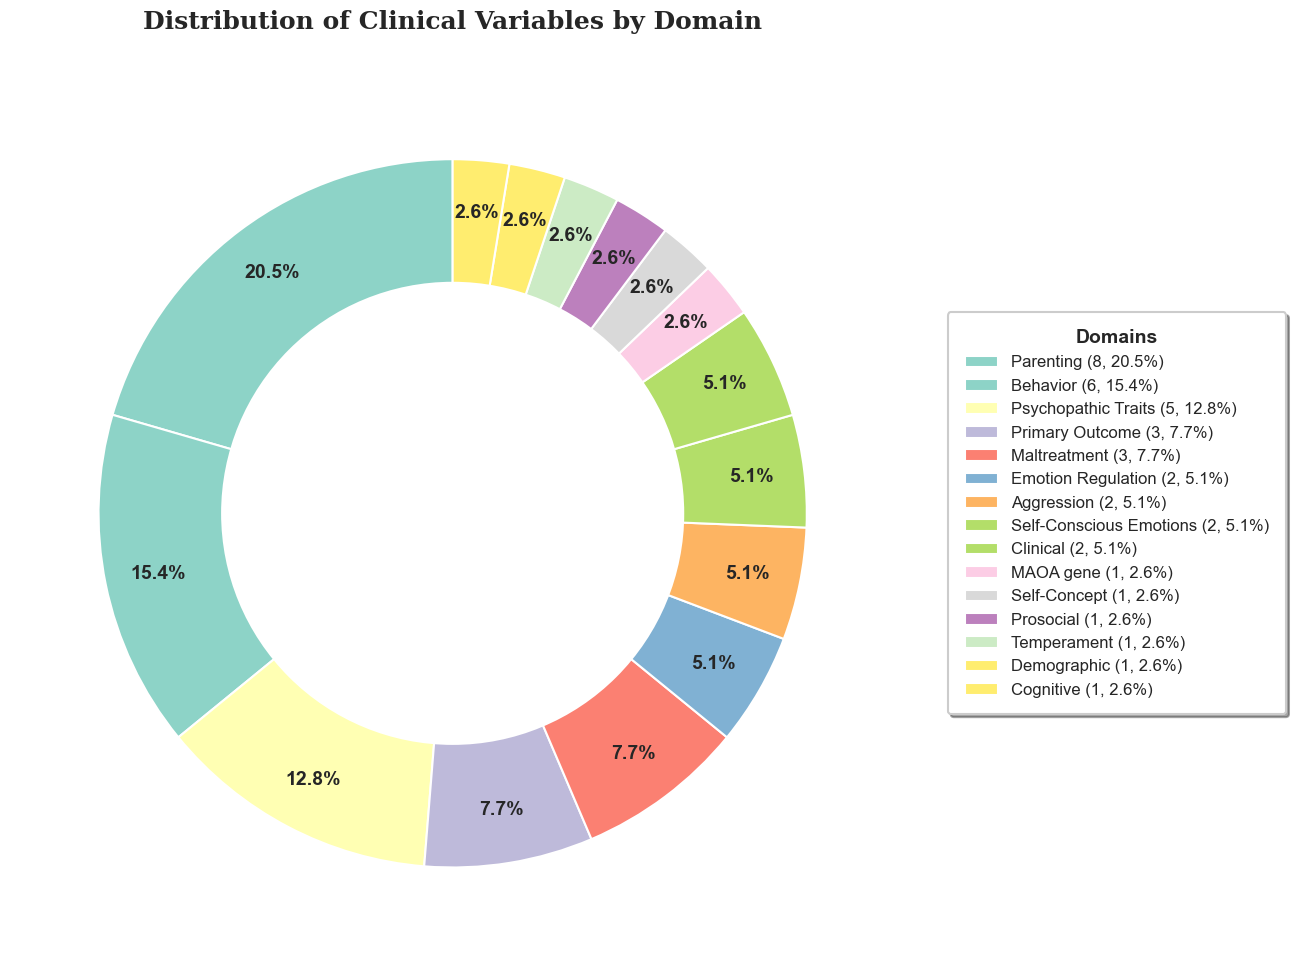


VARIABLES BY DOMAIN - SUMMARY STATISTICS
Total number of variables: 39
Number of distinct domains: 15

Detailed breakdown:
----------------------------------------------------------------------
Parenting                :  8 variables ( 20.5%)  ████████████████████
Behavior                 :  6 variables ( 15.4%)  ███████████████
Psychopathic Traits      :  5 variables ( 12.8%)  ████████████
Primary Outcome          :  3 variables (  7.7%)  ███████
Maltreatment             :  3 variables (  7.7%)  ███████
Emotion Regulation       :  2 variables (  5.1%)  █████
Aggression               :  2 variables (  5.1%)  █████
Self-Conscious Emotions  :  2 variables (  5.1%)  █████
Clinical                 :  2 variables (  5.1%)  █████
MAOA gene                :  1 variables (  2.6%)  ██
Self-Concept             :  1 variables (  2.6%)  ██
Prosocial                :  1 variables (  2.6%)  ██
Temperament              :  1 variables (  2.6%)  ██
Demographic              :  1 variables (  2.6%)  ██


In [121]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Data from your domain distribution
domains = ['Parenting', 'Behavior', 'Psychopathic Traits', 'Maltreatment', 
           'Primary Outcome', 'Clinical', 'Self-Conscious Emotions', 'Aggression',
           'Emotion Regulation', 'Cognitive', 'Demographic', 'Temperament', 
           'Prosocial', 'Self-Concept', 'MAOA gene']
counts = [8, 6, 5, 3, 3, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1]

# Sort by count (descending)
sorted_indices = np.argsort(counts)[::-1]
domains_sorted = [domains[i] for i in sorted_indices]
counts_sorted = [counts[i] for i in sorted_indices]

# ============================================
# DONUT CHART WITH LEGEND OUTSIDE (NO TOTAL IN CENTER)
# ============================================
fig, ax = plt.subplots(figsize=(14, 10))

# Create color scheme
colors = plt.cm.Set3(np.linspace(0, 1, len(domains_sorted)))

# Create donut chart
wedges, texts, autotexts = ax.pie(counts_sorted, 
                                   labels=None,  # No labels on pie
                                   colors=colors,
                                   autopct=lambda pct: f'{pct:.1f}%',
                                   startangle=90,
                                   pctdistance=0.85,
                                   textprops={'fontsize': 14, 'fontweight': 'bold'})

# Add a circle at the center to create donut effect (empty center)
centre_circle = plt.Circle((0, 0), 0.65, fc='white', linewidth=2, edgecolor='white')
ax.add_artist(centre_circle)

# REMOVED: The text in the center (no total variables displayed)

# Title with larger font
ax.set_title('Distribution of Clinical Variables by Domain', 
             fontsize=18, fontweight='bold', pad=30, fontfamily='serif')

# Create legend outside the pie chart (to the right)
legend_elements = []
for i, (domain, count) in enumerate(zip(domains_sorted, counts_sorted)):
    percentage = (count/sum(counts_sorted))*100
    legend_elements.append(Patch(facecolor=colors[i], 
                                  edgecolor='white',
                                  label=f'{domain} ({count}, {percentage:.1f}%)'))

# Add legend with larger font, placed outside to avoid overlap
legend = ax.legend(handles=legend_elements, 
                   title='Domains',
                   title_fontsize=14,
                   loc='center left',
                   bbox_to_anchor=(1.05, 0.5),
                   fontsize=12,
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   borderpad=1)

# Style the legend title
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(14)

# Adjust layout to make room for legend
plt.tight_layout()

# Save figure with high resolution
plt.savefig('variables_by_domain_donut.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('variables_by_domain_donut.pdf', bbox_inches='tight', facecolor='white')
plt.show()

# ============================================
# PRINT SUMMARY STATISTICS
# ============================================
print("\n" + "="*70)
print("VARIABLES BY DOMAIN - SUMMARY STATISTICS")
print("="*70)
print(f"Total number of variables: {sum(counts_sorted)}")
print(f"Number of distinct domains: {len(domains_sorted)}")
print("\nDetailed breakdown:")
print("-"*70)

for domain, count in zip(domains_sorted, counts_sorted):
    percentage = (count/sum(counts_sorted))*100
    bar = '█' * int(percentage)
    print(f"{domain:25s}: {count:2d} variables ({percentage:5.1f}%)  {bar}")

print("-"*70)
print(f"\nTop 3 domains accounting for most variables:")
for i in range(min(3, len(domains_sorted))):
    percentage = (counts_sorted[i]/sum(counts_sorted))*100
    print(f"  {i+1}. {domains_sorted[i]}: {counts_sorted[i]} variables ({percentage:.1f}%)")

print(f"\nBottom 6 domains (with 1 variable each):")
for i in range(-6, 0):
    print(f"  • {domains_sorted[i]}")

In [91]:
import os

# Check current working directory
print("Current working directory:", os.getcwd())

# List all files in the current directory
print("\nFiles in current directory:")
for file in os.listdir():
    if 'clinical' in file.lower() or 'variable' in file.lower():
        print(f"  - {file}")

Current working directory: /Users/zolf/Desktop/T1

Files in current directory:
  - clinical_variables_compact.xlsx
  - clinical_variables_table.tex
  - clinical_variables_summary.csv
  - clinical_variables_summary.xlsx


In [89]:
import pandas as pd
from IPython.display import display

# Simplified version without complex styling
variables_data = [
    ["QI", "Intelligence Quotient", "Wechsler Intelligence Scale for Children", "Cognitive"],
    ["Adhd", "ADHD Diagnosis", "Presence/absence of ADHD diagnosis (0=no, 1=yes)", "Clinical"],
    ["Cse", "Socioeconomic Status Index", "Composite measure of socioeconomic status", "Demographic"],
    ["Sintomi_DOP", "Oppositional Defiant Symptoms", "Severity of oppositional defiant symptoms", "Clinical"],
    ["Maltreatment_Emotional", "Emotional Maltreatment", "Being ridiculed, intimidated, exposed to hostility or violence", "Maltreatment"],
    ["Maltreatment_Neglect", "Neglect", "Left without supervision, insufficient nutrition", "Maltreatment"],
    ["Maltreatment_Physical", "Physical Maltreatment", "Intentionally physically hurt, suffocated, burned", "Maltreatment"],
    ["AD", "Anxiety-Depression", "Symptoms of anxiety and depression", "Behavior"],
    ["RBB", "Rule Breaking Behavior", "Behaviors violating rules and norms", "Behavior"],
    ["AB", "Aggressive Behavior", "Physically and verbally aggressive behaviors", "Behavior"],
    ["DP", "Dysregulation Profile", "Sum of aggressive behavior, attention problems, and anxiety-depression", "Behavior"],
    ["TOTINT", "Total Internalizing Problems", "Global internalizing symptoms score", "Behavior"],
    ["TOTEXT", "Total Externalizing Problems", "Global externalizing symptoms score", "Behavior"],
    ["APQ_POS", "Positive Parenting", "Global positive parenting score", "Parenting"],
    ["APQ_NEG", "Negative Parenting", "Global negative parenting score", "Parenting"],
    ["APQ_Coinv1", "Parental Involvement", "Participating in child's activities, spending time with child", "Parenting"],
    ["APQ_ParPos1", "Positive Parenting", "Encouraging, praising, warm relationship with child", "Parenting"],
    ["APQ_SS1", "Poor Supervision", "Child being outside without adult supervision", "Parenting"],
    ["APQ_DisInc1", "Inconsistent Discipline", "Threatening punishment without following through", "Parenting"],
    ["APQ_Pun1", "Physical Punishment", "Spanking, slapping, physical discipline", "Parenting"],
    ["APSD_CU1", "Callous-Unemotional Traits (APSD)", "Lack of guilt, reduced empathy", "Psychopathic Traits"],
    ["APSD_IMP1", "Impulsivity", "Acting without thinking, poor behavioral control", "Psychopathic Traits"],
    ["APSD_NAR1", "Narcissism", "Grandiosity, need for admiration", "Psychopathic Traits"],
    ["TOSCA_Shame", "Shame Proneness", "Tendency to experience shame", "Self-Conscious Emotions"],
    ["TOSCA_Guilt", "Guilt Proneness", "Tendency to experience guilt", "Self-Conscious Emotions"],
    ["HSC", "Environmental Sensitivity", "Sensitivity to environmental changes, sounds, smells", "Temperament"],
    ["AQ_Predatoria1", "Predatory Aggression", "Premeditated, covert, cold, goal-oriented aggression", "Aggression"],
    ["AQ_Reattiva1", "Reactive Aggression", "Affective, impulsive, uncontrolled aggression", "Aggression"],
    ["ERQ_CognReappr1", "Cognitive Reappraisal", "Ability to reinterpret situations to regulate emotions", "Emotion Regulation"],
    ["ERQ_ExprSuppor1", "Expressive Suppression", "Tendency to hide emotional expression", "Emotion Regulation"],
    ["SDQ_Prosocial1", "Prosocial Behavior", "Helping, sharing, caring behaviors", "Prosocial"],
    ["POS1", "Parental Overvaluation", "Belief that child is more special than others", "Parenting"],
    ["CNS1", "Childhood Narcissism", "Grandiose self-view, need for admiration", "Psychopathic Traits"],
    ["ICU_Total1", "Callous-Unemotional Traits (ICU)", "Global CU traits score", "Psychopathic Traits"],
    ["Self_Esteem1", "Self-Esteem", "Global self-esteem score", "Self-Concept"],
]

df = pd.DataFrame(variables_data, columns=["Variable", "Measure", "Description", "Domain"])

# Simple display
print("\n" + "="*100)
print("TABLE: Summary of Clinical Variables and Outcome Measures")
print("="*100)
display(df)

# Summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Total number of variables: {len(df)}")
print("\nVariables per domain:")
domain_counts = df['Domain'].value_counts()
for domain, count in domain_counts.items():
    print(f"  • {domain}: {count} variables")

# Save files
df.to_excel('clinical_variables_summary.xlsx', index=False)
df.to_csv('clinical_variables_summary.csv', index=False)
print("\n✓ Files saved: 'clinical_variables_summary.xlsx' and 'clinical_variables_summary.csv'")


TABLE: Summary of Clinical Variables and Outcome Measures


,Variable,Measure,Description,Domain
0,QI,Intelligence Quotient,Wechsler Intelligence Scale for Children,Cognitive
1,Adhd,ADHD Diagnosis,"Presence/absence of ADHD diagnosis (0=no, 1=yes)",Clinical
2,Cse,Socioeconomic Status Index,Composite measure of socioeconomic status,Demographic
3,Sintomi_DOP,Oppositional Defiant Symptoms,Severity of oppositional defiant symptoms,Clinical
4,Maltreatment_Emotional,Emotional Maltreatment,"Being ridiculed, intimidated, exposed to hosti...",Maltreatment
5,Maltreatment_Neglect,Neglect,"Left without supervision, insufficient nutrition",Maltreatment
6,Maltreatment_Physical,Physical Maltreatment,"Intentionally physically hurt, suffocated, burned",Maltreatment
7,AD,Anxiety-Depression,Symptoms of anxiety and depression,Behavior
8,RBB,Rule Breaking Behavior,Behaviors violating rules and norms,Behavior
9,AB,Aggressive Behavior,Physically and verbally aggressive behaviors,Behavior



SUMMARY STATISTICS
Total number of variables: 35

Variables per domain:
  • Parenting: 8 variables
  • Behavior: 6 variables
  • Psychopathic Traits: 5 variables
  • Maltreatment: 3 variables
  • Clinical: 2 variables
  • Self-Conscious Emotions: 2 variables
  • Aggression: 2 variables
  • Emotion Regulation: 2 variables
  • Cognitive: 1 variables
  • Demographic: 1 variables
  • Temperament: 1 variables
  • Prosocial: 1 variables
  • Self-Concept: 1 variables

✓ Files saved: 'clinical_variables_summary.xlsx' and 'clinical_variables_summary.csv'


/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_36206/3502291524.py:129: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_36206/3502291524.py:129: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_36206/3502291524.py:129: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from current font.
  plt.tight_layout()
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_36206/3502291524.py:129: UserWarning: Glyph 8324 (\N{SUBSCRIPT FOUR}) missing from current font.
  plt.tight_layout()
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_36206/3502291524.py:129: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from current font.
  plt.tight_layout()
/var/folders/f3/pdtgdwgd5yxdhtlmj2ktpxzh0000gn/T/ipykernel_36206/3502291524.py:130: UserWarning: Glyph 8321 (\N{SUBS

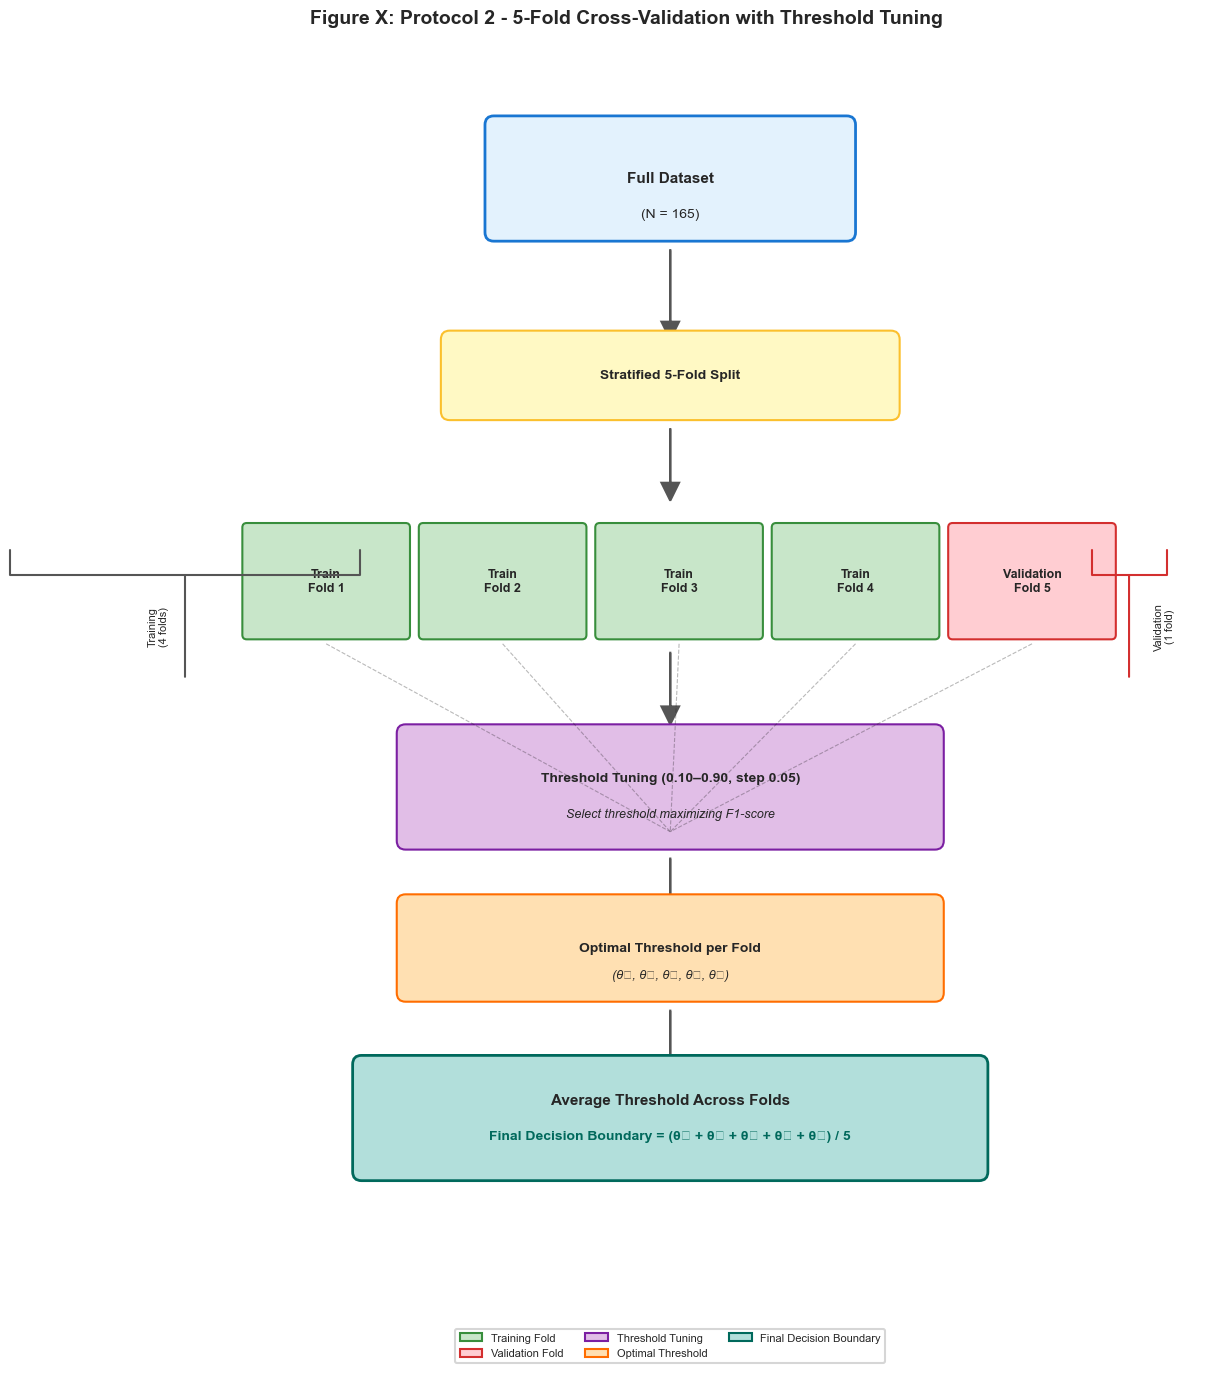

In [79]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(12, 14))
fig.suptitle('Figure X: Protocol 2 - 5-Fold Cross-Validation with Threshold Tuning', 
             fontsize=14, fontweight='bold', y=0.98)

ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis('off')

# ============================================
# Level 1: Full Dataset
# ============================================
dataset = FancyBboxPatch((4, 12), 4, 1.2, boxstyle="round,pad=0.1",
                         facecolor='#e3f2fd', edgecolor='#1976d2', linewidth=2)
ax.add_patch(dataset)
ax.text(6, 12.6, 'Full Dataset', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(6, 12.2, '(N = 165)', ha='center', va='center', fontsize=10)

# Arrow down
ax.arrow(6, 11.8, 0, -0.8, head_width=0.2, head_length=0.2, fc='#555', ec='#555', linewidth=1.5)

# ============================================
# Level 2: Stratified 5-Fold Split
# ============================================
split_text = FancyBboxPatch((3.5, 10), 5, 0.8, boxstyle="round,pad=0.1",
                            facecolor='#fff9c4', edgecolor='#fbc02d', linewidth=1.5)
ax.add_patch(split_text)
ax.text(6, 10.4, 'Stratified 5-Fold Split', ha='center', va='center', fontsize=10, fontweight='bold')

# Arrow down
ax.arrow(6, 9.8, 0, -0.6, head_width=0.2, head_length=0.2, fc='#555', ec='#555', linewidth=1.5)

# ============================================
# Level 3: 5 Folds Representation
# ============================================
# Fold positions (x, y, width, height)
fold_positions = [
    (1.2, 7.5, 1.8, 1.2),   # Fold 1
    (3.2, 7.5, 1.8, 1.2),   # Fold 2
    (5.2, 7.5, 1.8, 1.2),   # Fold 3
    (7.2, 7.5, 1.8, 1.2),   # Fold 4
    (9.2, 7.5, 1.8, 1.2)    # Fold 5
]

# Colors for folds (first 4 training, last validation)
fold_colors = ['#c8e6c9', '#c8e6c9', '#c8e6c9', '#c8e6c9', '#ffcdd2']
fold_edge = ['#388e3c', '#388e3c', '#388e3c', '#388e3c', '#d32f2f']

for i, (x, y, w, h) in enumerate(fold_positions):
    fold = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                          facecolor=fold_colors[i], edgecolor=fold_edge[i], linewidth=1.5)
    ax.add_patch(fold)
    
    if i < 4:
        ax.text(x + w/2, y + h/2, f'Train\nFold {i+1}', ha='center', va='center', fontsize=9, fontweight='bold')
    else:
        ax.text(x + w/2, y + h/2, f'Validation\nFold {i+1}', ha='center', va='center', fontsize=9, fontweight='bold')

# Add bracket to indicate training vs validation
ax.annotate('', xy=(0.5, 8.2), xytext=(0.5, 7.0),
            arrowprops=dict(arrowstyle='-[, widthB=7.0, lengthB=1.0', lw=1.5, color='#555'))
ax.text(0.2, 7.6, 'Training\n(4 folds)', ha='center', va='center', fontsize=8, rotation=90)

ax.annotate('', xy=(11.2, 8.2), xytext=(11.2, 7.0),
            arrowprops=dict(arrowstyle='-[, widthB=1.5, lengthB=1.0', lw=1.5, color='#d32f2f'))
ax.text(11.6, 7.6, 'Validation\n(1 fold)', ha='center', va='center', fontsize=8, rotation=90)

# Arrow down from folds to threshold tuning
ax.arrow(6, 7.3, 0, -0.6, head_width=0.2, head_length=0.2, fc='#555', ec='#555', linewidth=1.5)

# ============================================
# Level 4: Threshold Tuning
# ============================================
tuning_box = FancyBboxPatch((3, 5.2), 6, 1.2, boxstyle="round,pad=0.1",
                            facecolor='#e1bee7', edgecolor='#7b1fa2', linewidth=1.5)
ax.add_patch(tuning_box)
ax.text(6, 5.9, 'Threshold Tuning (0.10–0.90, step 0.05)', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(6, 5.5, 'Select threshold maximizing F1-score', ha='center', va='center', fontsize=9, style='italic')

# Arrow down
ax.arrow(6, 5.0, 0, -0.6, head_width=0.2, head_length=0.2, fc='#555', ec='#555', linewidth=1.5)

# ============================================
# Level 5: Optimal Threshold per Fold
# ============================================
thresholds_box = FancyBboxPatch((3, 3.5), 6, 1.0, boxstyle="round,pad=0.1",
                                facecolor='#ffe0b2', edgecolor='#ff6d00', linewidth=1.5)
ax.add_patch(thresholds_box)
ax.text(6, 4.0, 'Optimal Threshold per Fold', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(6, 3.7, '(θ₁, θ₂, θ₃, θ₄, θ₅)', ha='center', va='center', fontsize=9, style='italic')

# Arrow down
ax.arrow(6, 3.3, 0, -0.6, head_width=0.2, head_length=0.2, fc='#555', ec='#555', linewidth=1.5)

# ============================================
# Level 6: Final Decision Boundary
# ============================================
final_box = FancyBboxPatch((2.5, 1.5), 7, 1.2, boxstyle="round,pad=0.1",
                           facecolor='#b2dfdb', edgecolor='#00695c', linewidth=2)
ax.add_patch(final_box)
ax.text(6, 2.3, 'Average Threshold Across Folds', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(6, 1.9, 'Final Decision Boundary = (θ₁ + θ₂ + θ₃ + θ₄ + θ₅) / 5', 
        ha='center', va='center', fontsize=10, fontweight='bold', color='#00695c')

# ============================================
# Add horizontal flow indicators
# ============================================
# Dotted line connecting folds to threshold tuning
for i, (x, y, w, h) in enumerate(fold_positions):
    ax.plot([x + w/2, 6], [y - 0.1, 5.3], 'k--', alpha=0.3, linewidth=0.8)

# ============================================
# Add legend
# ============================================
legend_elements = [
    mpatches.Patch(facecolor='#c8e6c9', edgecolor='#388e3c', label='Training Fold'),
    mpatches.Patch(facecolor='#ffcdd2', edgecolor='#d32f2f', label='Validation Fold'),
    mpatches.Patch(facecolor='#e1bee7', edgecolor='#7b1fa2', label='Threshold Tuning'),
    mpatches.Patch(facecolor='#ffe0b2', edgecolor='#ff6d00', label='Optimal Threshold'),
    mpatches.Patch(facecolor='#b2dfdb', edgecolor='#00695c', label='Final Decision Boundary')
]

ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
          ncol=3, fontsize=8, frameon=True)

plt.tight_layout()
plt.savefig('protocol2_threshold_tuning.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [75]:
ax[1].set_xlim(0, 10)
ax[1].set_ylim(0, 12)
ax[1].axis('off')
ax[1].set_title('Protocol 2: 5-Fold Cross-Validation with Threshold Tuning', 
                fontsize=12, fontweight='bold', pad=20)

# Dataset box
dataset2 = FancyBboxPatch((3, 9), 4, 1.5, boxstyle="round,pad=0.1",
                          facecolor='#e3f2fd', edgecolor='#1976d2', linewidth=2)
ax[1].add_patch(dataset2)
ax[1].text(5, 9.75, 'Full Dataset\n(N = 165)', ha='center', va='center', fontsize=10)

# Arrow down
ax[1].arrow(5, 8.8, 0, -0.8, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

# 5-Fold representation
fold_positions = [(0.5, 6), (2.5, 6), (4.5, 6), (6.5, 6), (8.5, 6)]
fold_colors = ['#c8e6c9', '#c8e6c9', '#c8e6c9', '#c8e6c9', '#ffcdd2']

for i, (x, y) in enumerate(fold_positions):
    fold = FancyBboxPatch((x, y), 1.8, 1.2, boxstyle="round,pad=0.05",
                          facecolor=fold_colors[i], edgecolor='#388e3c' if i < 4 else '#d32f2f', 
                          linewidth=1.5)
    ax[1].add_patch(fold)
    
    if i < 4:
        ax[1].text(x+0.9, y+0.6, f'Train\nFold {i+1}', ha='center', va='center', fontsize=8)
    else:
        ax[1].text(x+0.9, y+0.6, f'Validation\nFold {i+1}', ha='center', va='center', fontsize=8)

# Arrow from dataset to folds
ax[1].arrow(5, 8.8, 0, -1.2, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

# Text for cross-validation process
ax[1].text(5, 7.3, 'Stratified 5-Fold Split', ha='center', fontsize=9, style='italic',
           bbox=dict(boxstyle="round,pad=0.3", facecolor='#fff9c4', edgecolor='none'))

# Threshold tuning box
tuning = FancyBboxPatch((3, 3.5), 4, 1.2, boxstyle="round,pad=0.1",
                        facecolor='#e1bee7', edgecolor='#7b1fa2', linewidth=1.5)
ax[1].add_patch(tuning)
ax[1].text(5, 4.1, 'Threshold Tuning (0.10-0.90, step 0.05)\nSelect threshold maximizing F1-score', 
           ha='center', va='center', fontsize=8)

# Arrow from folds to tuning
ax[1].arrow(5, 6, 0, -1.2, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

# Optimal threshold per fold
thresholds = FancyBboxPatch((3, 1.8), 4, 1, boxstyle="round,pad=0.1",
                            facecolor='#ffe0b2', edgecolor='#ff6d00', linewidth=1.5)
ax[1].add_patch(thresholds)
ax[1].text(5, 2.3, 'Optimal Threshold per Fold', ha='center', va='center', fontsize=9)

# Final average threshold
final = FancyBboxPatch((3, 0.3), 4, 1, boxstyle="round,pad=0.1",
                       facecolor='#b2dfdb', edgecolor='#00695c', linewidth=1.5)
ax[1].add_patch(final)
ax[1].text(5, 0.8, 'Average Threshold Across Folds\nFinal Decision Boundary', 
           ha='center', va='center', fontsize=9)

# Arrow from thresholds to final
ax[1].arrow(5, 1.7, 0, -0.6, head_width=0.2, head_length=0.2, fc='gray', ec='gray')

plt.tight_layout()
plt.savefig('evaluation_protocols_schematic.png', dpi=300, bbox_inches='tight', 
            facecolor='white')
plt.show()

<Figure size 640x480 with 0 Axes>

✓ Figure saved as 'class_imbalance_table.png'


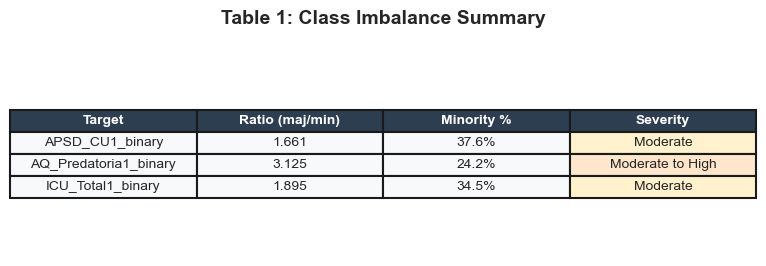

In [71]:
def create_figure_table(df, title="Table 1: Class Imbalance Summary"):
    """Create a matplotlib figure with table for thesis"""
    
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.axis('tight')
    ax.axis('off')
    
    # Prepare data for table
    table_data = df.values.tolist()
    columns = df.columns.tolist()
    
    # Create table
    table = ax.table(cellText=table_data,
                     colLabels=columns,
                     cellLoc='center',
                     loc='center',
                     colColours=['#2c3e50']*len(columns))
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Color header
    for (i, j), cell in table.get_celld().items():
        if i == 0:  # Header row
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#2c3e50')
        else:
            cell.set_facecolor('#f8f9fa')
            
            # Color severity column based on value
            if j == 3:  # Severity column
                value = table_data[i-1][j]
                if value == 'High':
                    cell.set_facecolor('#ffcccc')
                elif value == 'Moderate to High':
                    cell.set_facecolor('#ffe6cc')
                elif value == 'Moderate':
                    cell.set_facecolor('#fff2cc')
    
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Save figure
    plt.savefig('class_imbalance_table.png', dpi=300, bbox_inches='tight', 
                facecolor='white')
    print("✓ Figure saved as 'class_imbalance_table.png'")
    
    plt.show()

# Create figure table
create_figure_table(final_table)

In [23]:
# Cell 10: check distributions of binary targets

binary_targets = [c for c in df.columns if c.endswith('_binary')]
for col in binary_targets:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



APSD_CU1_binary value counts:
APSD_CU1_binary
0    103
1     62
Name: count, dtype: int64

AQ_Predatoria1_binary value counts:
AQ_Predatoria1_binary
0    125
1     40
Name: count, dtype: int64

ICU_Total1_binary value counts:
ICU_Total1_binary
0    108
1     57
Name: count, dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


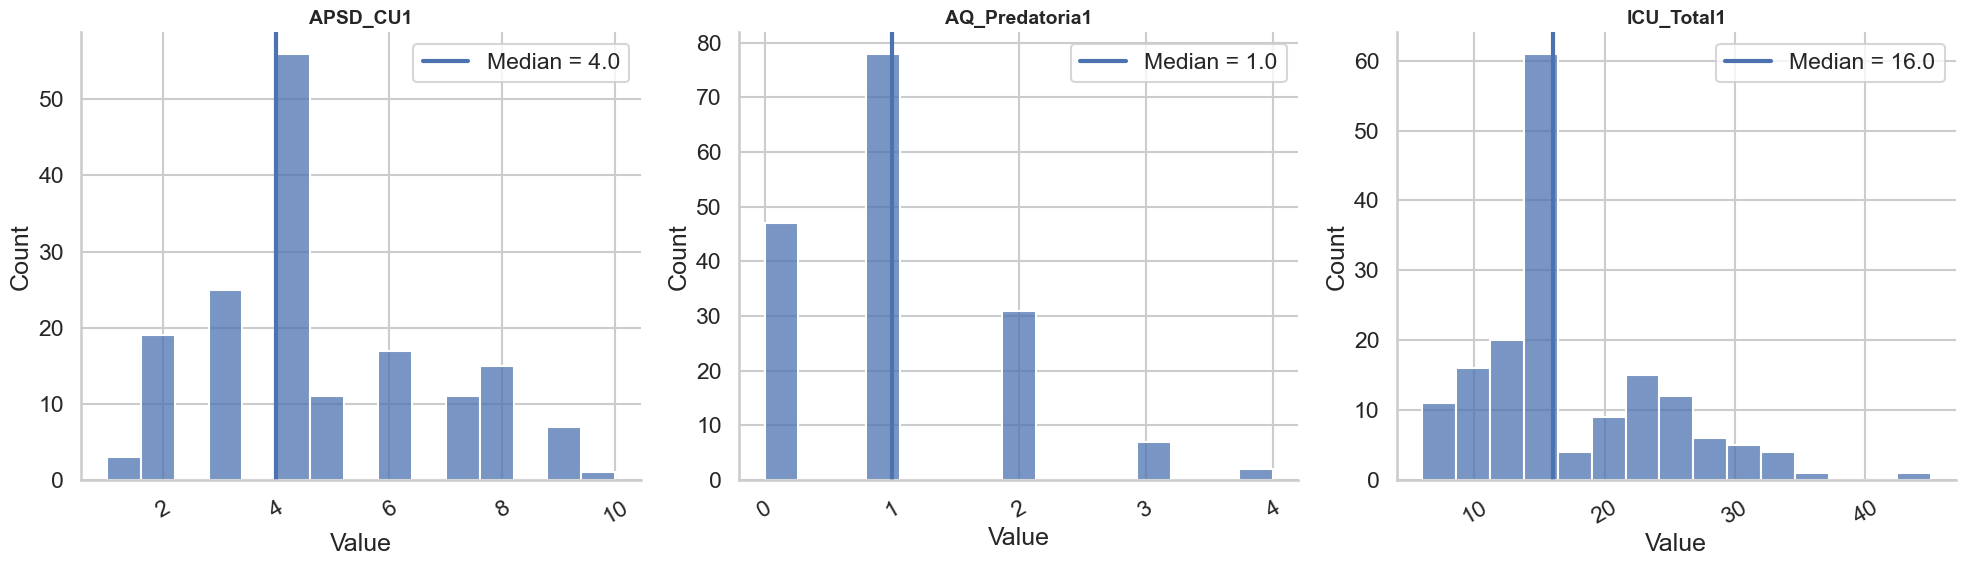

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid", context="talk")

target_cont = ['APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']

# Medians
medians = {
    'APSD_CU1': 4.0,
    'AQ_Predatoria1': 1.0,
    'ICU_Total1': 16.0
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, target_cont):
    
    # ✅ SAME plotting method for all
    sns.histplot(
        df[col],
        bins=15,
        kde=False,   # remove KDE for consistency
        ax=ax
    )
    
    # Median line
    median_val = medians[col]
    ax.axvline(
        median_val,
        linewidth=3,
        label=f'Median = {median_val}'
    )
    
    # Titles and labels
    ax.set_title(col, fontsize=14, weight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    
    # Clean look
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [136]:
# Cell 11: build X and y_clf (features and classification targets)

target_bin = [c for c in df.columns if c.endswith('_binary')]
all_targets = target_cont + target_bin

# ID-like columns to exclude if present
id_like = ['ID', 'Nome', 'Unnamed:0', 'Unnamed:1']

exclude_cols = all_targets + id_like
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y_clf = df[target_bin].copy()

print("Feature columns:", len(feature_cols))
print("Classification targets:", target_bin)


Feature columns: 40
Classification targets: ['APSD_CU1_binary', 'AQ_Predatoria1_binary', 'ICU_Total1_binary']


In [138]:
# Cell 12: one-hot encode categorical features in X

cat_in_X = X.select_dtypes(include=['object']).columns
print("Categorical features to encode:", list(cat_in_X))

X = pd.get_dummies(X, columns=cat_in_X, drop_first=True)

print("X shape after encoding:", X.shape)


Categorical features to encode: []
X shape after encoding: (165, 40)


In [140]:
print(f"Number of feature columns: {len(feature_cols)}")
print("Feature columns:")
for c in feature_cols:
    print("-", c)


Number of feature columns: 40
Feature columns:
- MAOAuVNTR
- Eta
- QI
- adhd
- farmaco
- cse
- emotional
- neglect
- physical
- AD
- RBB
- AB
- TOTINT
- TOTEXT
- APQ_POS
- APQ_NEG
- APSD_CU
- APSD_IMP
- APSD_NARCI
- Sintomi_DOP
- ER_paura
- ER_tristezza
- ER_rabbia
- ER_felicità
- ER_disgusto
- FC_E_AN
- FC_E_HA
- FC_E_SA
- FC_E_FE
- FC_E_DI
- FFD_E_AN
- FFD_E_HA
- FFD_E_SA
- FFD_E_FE
- FFD_E_DI
- FD_E_AN
- FD_E_HA
- FD_E_SA
- FD_E_FE
- FD_E_DI


In [142]:
# Cell 13: check no target columns are in X

leaked = [c for c in all_targets if c in X.columns]
print("Leaked target columns inside X:", leaked)


Leaked target columns inside X: []


In [166]:
def evaluateBinaryClassification(predictions, actuals):
    contigency = pd.crosstab(actuals, predictions)

    TP = contigency[1][1] if (1 in contigency.index and 1 in contigency.columns) else 0
    TN = contigency[0][0] if (0 in contigency.index and 0 in contigency.columns) else 0
    FP = contigency[0][1] if (0 in contigency.index and 1 in contigency.columns) else 0
    FN = contigency[1][0] if (1 in contigency.index and 0 in contigency.columns) else 0

    print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

In [148]:
# standardize data
scaler = preprocessing.StandardScaler()

scaler.fit(X)  # Note the use of an array of column names

X = pd.DataFrame(scaler.transform(X),columns =X.columns)
X.describe()

,MAOAuVNTR,Eta,QI,adhd,farmaco,cse,emotional,neglect,physical,AD,RBB,AB,TOTINT,TOTEXT,APQ_POS,APQ_NEG,APSD_CU,APSD_IMP,APSD_NARCI,Sintomi_DOP,ER_paura,ER_tristezza,ER_rabbia,ER_felicità,ER_disgusto,FC_E_AN,FC_E_HA,FC_E_SA,FC_E_FE,FC_E_DI,FFD_E_AN,FFD_E_HA,FFD_E_SA,FFD_E_FE,FFD_E_DI,FD_E_AN,FD_E_HA,FD_E_SA,FD_E_FE,FD_E_DI
count,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02,1.650000e+02
mean,2.180074e-16,1.937844e-16,-3.875688e-16,-1.399554e-16,4.306320e-17,1.009294e-16,-1.076580e-17,1.291896e-16,-7.536059e-17,-5.167584e-16,2.664535e-16,-2.206989e-16,1.076580e-17,7.105427e-16,-3.445056e-16,1.291896e-16,-1.345725e-16,2.153160e-17,-2.691450e-17,-4.306320e-17,1.520669e-16,-1.776357e-16,1.184238e-16,-2.395390e-16,-6.459479e-17,1.453383e-16,-1.507212e-16,6.190334e-17,-4.925353e-16,-3.983346e-16,2.153160e-16,-8.612639e-17,4.306320e-16,4.736952e-16,4.306320e-17,1.076580e-16,-3.337398e-16,-2.745279e-16,4.360149e-16,1.937844e-16
std,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00,1.003044e+00
min,-3.787111e+00,-1.402413e+00,-2.360777e+00,-1.414214e+00,-4.507400e-01,-1.303891e+00,-8.205588e-01,-4.380188e-01,-4.225771e-01,-2.184396e+00,-2.277929e+00,-2.440635e+00,-3.990849e+00,-3.706591e+00,-2.115000e+00,-2.546171e+00,-1.689705e+00,-3.047035e+00,-1.738260e+00,-3.037317e+00,-1.975679e+00,-2.127724e+00,-3.727862e+00,-4.352768e+00,-2.184470e+00,-2.222751e+00,-2.859307e+00,-2.020787e+00,-2.490126e+00,-2.494048e+00,-2.194347e+00,-2.465278e+00,-2.320708e+00,-2.031273e+00,-2.275576e+00,-2.345934e+00,-2.691902e+00,-1.816670e+00,-2.359228e+00,-2.459006e+00
25%,-1.590720e+00,-8.501500e-01,-5.881800e-01,-1.414214e+00,-4.507400e-01,-1.303891e+00,-8.205588e-01,-4.380188e-01,-4.225771e-01,-5.853483e-01,-5.710340e-01,-6.705040e-01,-5.901119e-01,-6.122495e-01,-6.394185e-01,-7.682690e-01,-7.603673e-01,-8.776250e-01,-6.222564e-01,-9.286607e-01,-1.021903e-01,-1.934295e-01,1.488012e-01,-6.314897e-01,-2.414105e-01,-5.886527e-01,-3.761521e-01,-6.087606e-01,-5.846060e-01,-5.940644e-01,-6.254444e-01,-4.547956e-01,-5.776634e-01,-5.441688e-01,-5.139176e-01,-5.469377e-01,-3.539652e-01,-5.153456e-01,-4.977637e-01,-5.520808e-01
50%,6.056715e-01,-2.978872e-01,-3.424335e-02,7.071068e-01,1.539112e-01,4.311254e-01,-8.205588e-01,-4.380188e-01,-4.225771e-01,-1.056340e-01,-5.896547e-02,-3.754822e-01,-5.315347e-02,-2.482092e-01,-1.475581e-01,-5.710836e-02,-2.956984e-01,2.070800e-01,-2.502553e-01,-2.257753e-01,-1.021903e-01,-1.934295e-01,1.488012e-01,6.089365e-01,-2.414105e-01,5.824275e-02,1.204790e-01,-1.404239e-02,1.439460e-01,8.154570e-02,-1.119825e-01,-1.237673e-01,-1.251933e-01,-2.066567e-01,-1.914137e-01,8.529144e-02,9.713853e-03,2.850930e-03,1.500897e-01,4.661737e-02
75%,6.056715e-01,2.543756e-01,6.304806e-01,7.071068e-01,1.539112e-01,4.311254e-01,6.837990e-01,-4.380188e-01,-4.225771e-01,8.537944e-01,6.237926e-01,3.620722e-01,6.627912e-01,6.618913e-01,5.902324e-01,8.318425e-01,6.336394e-01,7.494326e-01,4.937469e-01,4.771101e-01,8.345540e-01,7.737179e-01,1.488012e-01,6.089365e-01,7.301195e-01,5.438034e-01,5.326828e-01,6.266548e-01,6.243209e-01,5.170720e-01,3.870643e-01

In [150]:
X_train, X_test, y_train, y_test = train_test_split(X, y_clf,  test_size=0.3,random_state=1)

print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)

(115, 40) (50, 40) (115, 3) (50, 3)


         feature  importance       std
7        neglect    0.004930  0.011354
8       physical    0.005596  0.011856
4        farmaco    0.005725  0.012204
3           adhd    0.005861  0.012282
23   ER_felicità    0.006157  0.015701
5            cse    0.006992  0.012397
6      emotional    0.007547  0.013425
0      MAOAuVNTR    0.010086  0.028646
22     ER_rabbia    0.014104  0.026903
1            Eta    0.014582  0.019487
17      APSD_IMP    0.014936  0.020323
30      FFD_E_AN    0.016215  0.023606
20      ER_paura    0.016644  0.024765
18    APSD_NARCI    0.016945  0.022472
16       APSD_CU    0.017256  0.023258
12        TOTINT    0.018664  0.022903
10           RBB    0.019662  0.022944
19   Sintomi_DOP    0.019749  0.027054
13        TOTEXT    0.020080  0.025486
31      FFD_E_HA    0.021391  0.029324
14       APQ_POS    0.021923  0.025223
32      FFD_E_SA    0.022125  0.029965
2             QI    0.022648  0.025711
34      FFD_E_DI    0.023364  0.030130
15       APQ_NEG    0.023

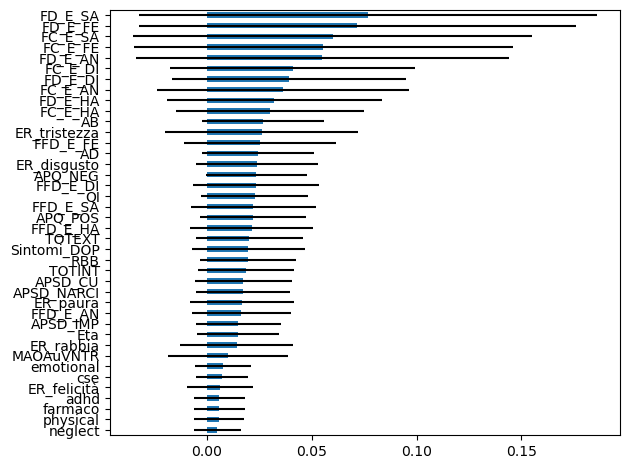

In [152]:
rf = RandomForestClassifier(n_estimators=1000,random_state=2)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

df = pd.DataFrame({'feature': X_train.columns, 'importance': importances, 'std': std})
df = df.sort_values('importance')
print(df)

ax = df.plot(kind='barh', xerr='std', x='feature', legend=False)
ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [119]:
select_features=df[df.importance>=0.05].feature

AttributeError: 'DataFrame' object has no attribute 'importance'

In [117]:
print(select_features.tolist())

NameError: name 'select_features' is not defined

In [160]:
knn = KNeighborsClassifier(n_neighbors=1, weights='uniform')
knn.fit(X_train[select_features], y_train)

y_predict_knn = knn.predict(X_test[select_features])

# 🔽 replace the old crosstab with this
for i, col in enumerate(y_train.columns):
    print(f"\nConfusion matrix for {col}:")
    print(pd.crosstab(y_test.iloc[:, i], y_predict_knn[:, i]))


Confusion matrix for APSD_CU1_binary:
col_0             0  1
APSD_CU1_binary       
0                30  7
1                 6  7

Confusion matrix for AQ_Predatoria1_binary:
col_0                   0  1
AQ_Predatoria1_binary       
0                      35  5
1                       8  2

Confusion matrix for ICU_Total1_binary:
col_0               0  1
ICU_Total1_binary       
0                  30  5
1                   6  9


In [168]:
for i, col in enumerate(y_train.columns):
    print(f"\nEvaluating {col}:")
    evaluateBinaryClassification(
        y_predict_knn[:, i],
        y_test.iloc[:, i]
    )


Evaluating APSD_CU1_binary:
TP: 7 TN: 30 FP: 6 FN: 7

Evaluating AQ_Predatoria1_binary:
TP: 2 TN: 35 FP: 8 FN: 5

Evaluating ICU_Total1_binary:
TP: 9 TN: 30 FP: 6 FN: 5


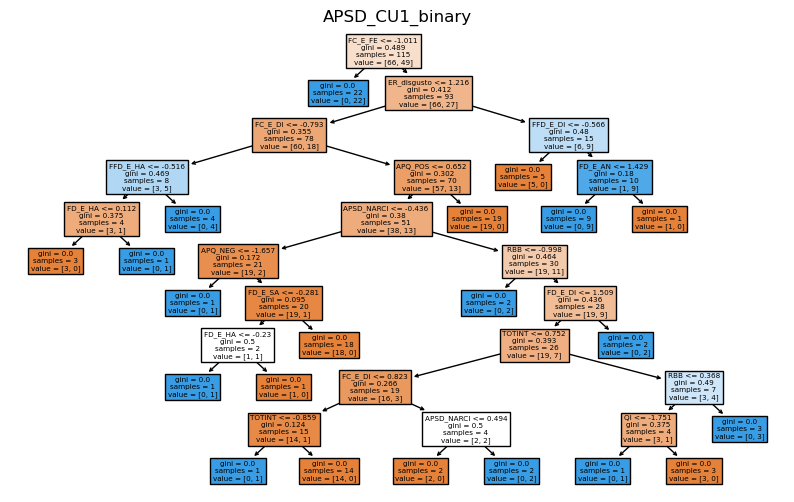

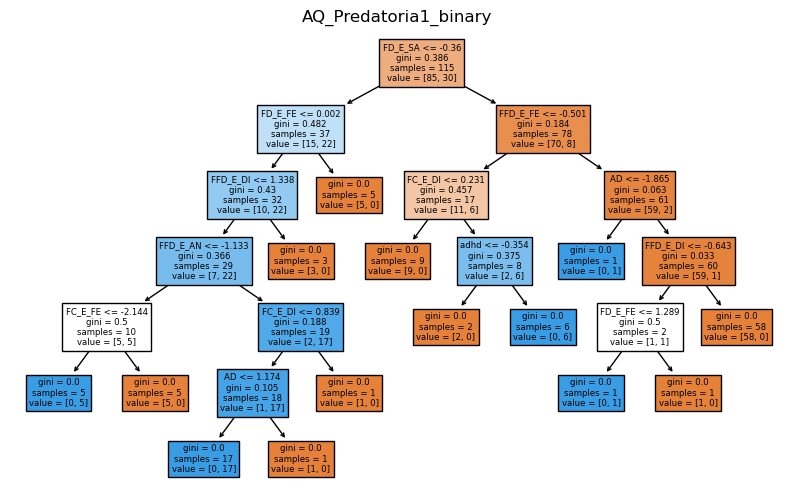

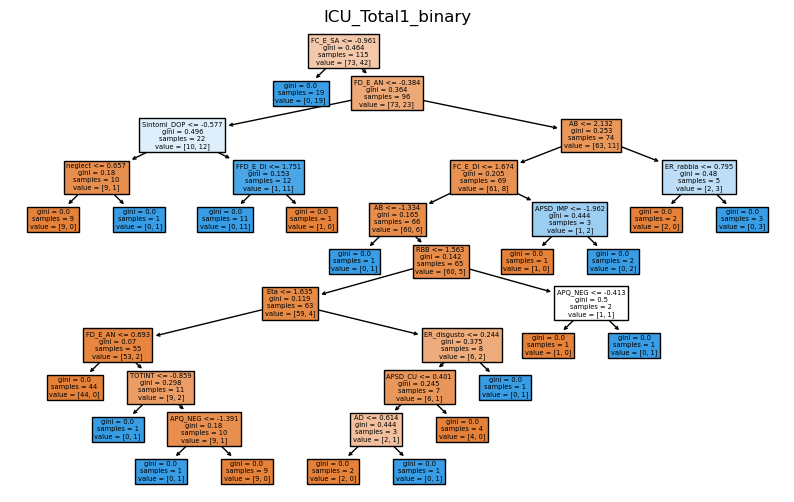

In [174]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

for i, col in enumerate(y_train.columns):
    tree = DecisionTreeClassifier()
    tree.fit(X_train, y_train.iloc[:, i])

    plt.figure(figsize=(10,6))
    plot_tree(tree, feature_names=X_train.columns, filled=True)
    plt.title(col)
    plt.show()

In [202]:
compare_df = pd.DataFrame(columns=y_train.columns)

In [204]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(max_iter=500)
mlp.fit(X_train, y_train)

y_predict_mlp = mlp.predict(X_test)

for i, col in enumerate(y_train.columns):
    compare_df.loc['MLP', col] = evaluateBinaryClassification(
        y_predict_mlp[:, i],
        y_test.iloc[:, i]
    )

TP: 8 TN: 31 FP: 5 FN: 6
TP: 3 TN: 34 FP: 7 FN: 6
TP: 7 TN: 34 FP: 8 FN: 1


/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [208]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier

nb = MultiOutputClassifier(MultinomialNB())
nb.fit(X_train, y_train)

y_predict_nb = nb.predict(X_test)

for i, col in enumerate(y_train.columns):
    compare_df.loc['NB', col] = evaluateBinaryClassification(
        y_predict_nb[:, i],
        y_test.iloc[:, i]
    )

ValueError: Negative values in data passed to MultinomialNB (input X)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [210]:
compare_df

,APSD_CU1_binary,AQ_Predatoria1_binary,ICU_Total1_binary
MLP,None,None,None


In [212]:
from sklearn.metrics import accuracy_score

for model_name, preds in {
    'KNN': y_predict_knn,
    'DT': y_predict_dt,
    'MLP': y_predict_mlp,
    'NB': y_predict_nb
}.items():
    
    for i, col in enumerate(y_train.columns):
        compare_df.loc[model_name, col] = accuracy_score(
            y_test.iloc[:, i],
            preds[:, i]
        )

NameError: name 'y_predict_nb' is not defined

In [123]:
import pandas as pd

# Create the data with AUC
data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'],
    'APSD_CU1': [0.76, 0.74, 0.74, 0.74, 0.78],
    'AQ_Predatoria1': [0.67, 0.64, 0.70, 0.63, 0.71],
    'ICU_Total1': [0.52, 0.54, 0.55, 0.51, 0.69]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display with formatting
print("\n=== ANN Model Performance Summary ===\n")
print(df.to_string(index=False))

# Optional: Save to CSV
df.to_csv('ann_performance_metrics.csv', index=False)
print("\nTable saved as 'ann_performance_metrics.csv'")


=== ANN Model Performance Summary ===

   Metric  APSD_CU1  AQ_Predatoria1  ICU_Total1
 Accuracy      0.76            0.67        0.52
Precision      0.74            0.64        0.54
   Recall      0.74            0.70        0.55
 F1-score      0.74            0.63        0.51
      AUC      0.78            0.71        0.69

Table saved as 'ann_performance_metrics.csv'


In [125]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Create single figure
plt.figure(figsize=(10, 8))

# Plot ROC curves for all three targets
plt.plot(fpr_apsd, tpr_apsd, lw=2, label=f'APSD_CU1 (AUC = 0.78)', color='#2E86AB')
plt.plot(fpr_aq, tpr_aq, lw=2, label=f'AQ_Predatoria1 (AUC = 0.71)', color='#A23B72')
plt.plot(fpr_icu, tpr_icu, lw=2, label=f'ICU_Total1 (AUC = 0.69)', color='#F18F01')

# Plot random baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.50)', alpha=0.7)

# Labels and title
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: ANN Model Performance Across Target Variables', fontsize=14, fontweight='bold')

# Legend
plt.legend(loc="lower right", fontsize=10)

# Grid
plt.grid(True, alpha=0.3)

# Set limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Save and show
plt.tight_layout()
plt.savefig('roc_curves_combined.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'fpr_apsd' is not defined

<Figure size 1000x800 with 0 Axes>

NameError: name 'fpr_apsd' is not defined

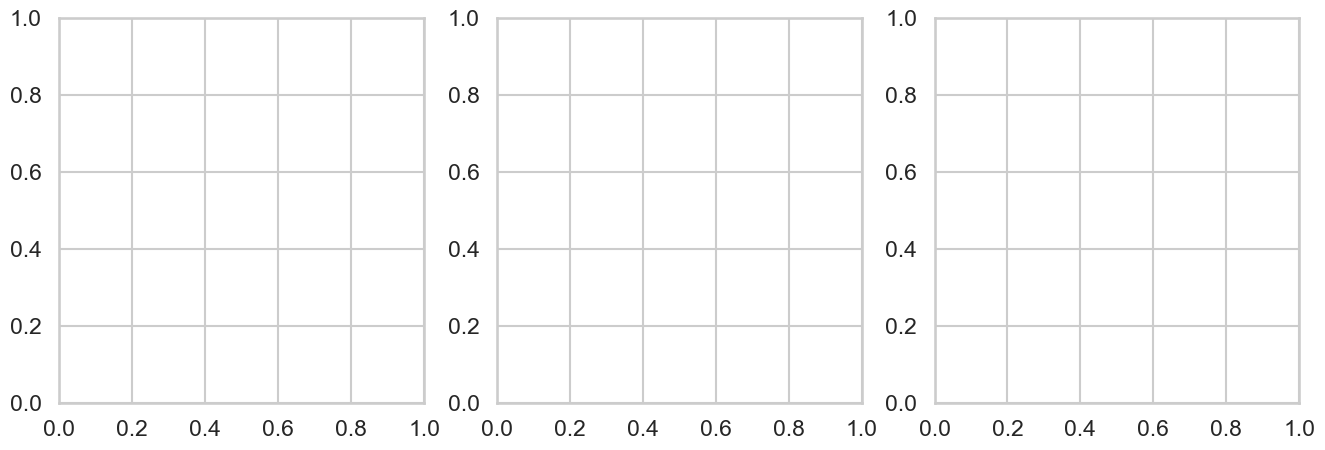

In [127]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Define custom colors
colors = ['#2E86AB', '#A23B72', '#F18F01']
targets = ['APSD_CU1', 'AQ_Predatoria1', 'ICU_Total1']
auc_scores = [0.78, 0.71, 0.69]  # Your AUC values

# Assuming you have your data
# For each target, calculate ROC curve
# Replace these with your actual data
all_fpr = [fpr_apsd, fpr_aq, fpr_icu]  # Your FPR arrays
all_tpr = [tpr_apsd, tpr_aq, tpr_icu]  # Your TPR arrays

for idx, (ax, target, color, auc) in enumerate(zip(axes, targets, colors, auc_scores)):
    # Plot ROC curve
    ax.plot(all_fpr[idx], all_tpr[idx], color=color, lw=2.5, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.7, label='Random')
    
    # Set limits
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    
    # Set labels
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    
    # Set title
    ax.set_title(target, fontsize=13, fontweight='bold', pad=10)
    
    # Add legend
    ax.legend(loc="lower right", fontsize=9)
    
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add background color
    ax.set_facecolor('#f8f9fa')
    
    # Add text with AUC value in the plot
    ax.text(0.05, 0.92, f'AUC = {auc:.3f}', transform=ax.transAxes, 
            fontsize=11, fontweight='bold', 
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Add main title
plt.suptitle('ROC Curves: ANN Model Performance', fontsize=16, fontweight='bold', y=1.02)

# Adjust spacing
plt.tight_layout()

# Save the figure
plt.savefig('roc_curves_side_by_side.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()